# Chest X-Ray (Pneumonia Classification)

In [2]:
import torch.nn as nn
from torchvision import models
import torch.nn.functional as F
from torch.optim import Adam
import torchvision.transforms as transforms
import torchvision.datasets as datasets


1) 이미지 전처리 및 가져오기

EfficientNet 같은 모델을 pretrained=True로 불러오면, ImageNet 데이터로 학습된 가중치를 가져옵니다.
→ 이때 입력 데이터 분포가 ImageNet 이미지와 최대한 비슷하게 정규화되어야, pretrained weight가 잘 동작

In [ ]:
transforms_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transforms_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


## 이미지를 정답데이터별로 labeling 해서 가져와줌
train_datasets = datasets.ImageFolder(root='../../data_resources/chest_xray/train', transform=transforms_train)
test_datasets = datasets.ImageFolder(root="../../data_resources/chest_xray/test", transform=transforms_test)

- train_datasets 의 채널 수 확인
- transforms.ToTensor()가 RGB 3채널로 변환해줌

In [15]:
img, label = train_datasets[0]
print(img.shape)
print(label)

torch.Size([3, 224, 224])
0


- 클래스 불균형 확인해보기

In [22]:
from collections import Counter
import numpy as np

# 1) 클래스 이름과 인덱스 매핑
print("class_to_idx:", train_datasets.class_to_idx)   # 예: {'NORMAL': 0, 'PNEUMONIA': 1}
print("classes    :", train_datasets.classes)

# 2) 클래스별 샘플 수 (train)
train_labels = [y for _, y in train_datasets.samples]   # 또는 train_datasets.targets (torchvision 버전에 따라 존재)
train_cnt = Counter(train_labels)
total = sum(train_cnt.values())

print("\n[Train] class counts:")
for cls_idx, cnt in sorted(train_cnt.items()):
    cls_name = train_datasets.classes[cls_idx]
    print(f"  {cls_name} ({cls_idx}): {cnt}  ({cnt/total:.2%})")

# 3) 테스트셋도 동일하게
test_labels = [y for _, y in test_datasets.samples]
test_cnt = Counter(test_labels)
total_t = sum(test_cnt.values())

print("\n[Test] class counts:")
for cls_idx, cnt in sorted(test_cnt.items()):
    cls_name = test_datasets.classes[cls_idx]
    print(f"  {cls_name} ({cls_idx}): {cnt}  ({cnt/total_t:.2%})")


class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}
classes    : ['NORMAL', 'PNEUMONIA']

[Train] class counts:
  NORMAL (0): 1341  (25.71%)
  PNEUMONIA (1): 3875  (74.29%)

[Test] class counts:
  NORMAL (0): 234  (37.50%)
  PNEUMONIA (1): 390  (62.50%)


- 잘불러와졌나 확인해보기

In [5]:
train_datasets.classes
test_datasets.classes

['NORMAL', 'PNEUMONIA']

In [6]:
test_datasets

Dataset ImageFolder
    Number of datapoints: 624
    Root location: ../../data_resources/chest_xray/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

2. 데이터를 Dataloader 이용해서 mini batch 사이즈로 나누기

In [7]:
import torch 
train_dataloader = torch.utils.data.DataLoader(train_datasets, batch_size=20, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_datasets, batch_size=20, shuffle=False)

In [12]:
## train_dataloader의 첫번째 미니 배치 데이터 확인

print(len(next(iter(train_dataloader))[0]))
next(iter(train_dataloader))[0]

20


tensor([[[[-1.2445, -1.1932, -1.1247,  ...,  0.0227,  0.1254,  0.1768],
          [-1.2445, -1.1760, -1.0733,  ...,  0.0569,  0.0912,  0.1254],
          [-1.2274, -1.1247, -1.0219,  ...,  0.0741,  0.0741,  0.0912],
          ...,
          [-1.8782, -1.8782, -1.8782,  ..., -1.9638, -1.9467, -1.9638],
          [-1.8782, -1.8953, -1.8953,  ..., -1.9638, -1.9809, -1.9809],
          [-1.8782, -1.8953, -1.8953,  ..., -1.9638, -1.9980, -1.9809]],

         [[-1.1429, -1.0903, -1.0203,  ...,  0.1527,  0.2577,  0.3102],
          [-1.1429, -1.0728, -0.9678,  ...,  0.1877,  0.2227,  0.2577],
          [-1.1253, -1.0203, -0.9153,  ...,  0.2052,  0.2052,  0.2227],
          ...,
          [-1.7906, -1.7906, -1.7906,  ..., -1.8782, -1.8606, -1.8782],
          [-1.7906, -1.8081, -1.8081,  ..., -1.8782, -1.8957, -1.8957],
          [-1.7906, -1.8081, -1.8081,  ..., -1.8782, -1.9132, -1.8957]],

         [[-0.9156, -0.8633, -0.7936,  ...,  0.3742,  0.4788,  0.5311],
          [-0.9156, -0.8458, -

3. 이미지 확인해보기

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
## 이미지 시각화를 함수로 정의

def imshow(img, title):
    img = img.numpy().transpose((1,2,0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()
    

배치 단위로 묶어서 출력

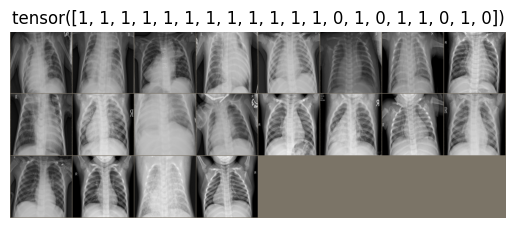

In [16]:
import torchvision

images, labels = next(iter(train_dataloader))
images_data = torchvision.utils.make_grid(images)

imshow(images_data, labels)

4. 모델 생성

In [17]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

efficientNet 생성 함수 만들기 저장된 weights 불러오기

In [21]:
def build_efficientNet():
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)

    #출력층을 이진 로짓 하나로 교체
    model.classifier[1] = nn.Linear(in_features=1280, out_features=1, bias=True)

    return model

In [20]:
model = build_efficientNet()
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

5. 모델 학습

In [24]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

pos_weight = torch.tensor([1341/3875], device=device)

In [27]:
from tensorboardX import SummaryWriter
from tqdm import tqdm
writer = SummaryWriter()

lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
epochs = 30
step = 0

model.to(device)

for epoch in range(epochs):
    for images, labels in tqdm(train_dataloader):
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1) # [B] -> [B,1]
        optimizer.zero_grad()

        preds = model(images)
        loss = criterion(preds, labels)

        loss.backward()
        optimizer.step()

        writer.add_scalar('Loss/train', loss.item(), step)
        step += 1

    print(f"{epoch} epoch loss: {loss.item()}")


  0%|          | 0/261 [00:00<?, ?it/s]

100%|██████████| 261/261 [02:12<00:00,  1.97it/s]


0 epoch loss: 0.3641682267189026


100%|██████████| 261/261 [04:24<00:00,  1.01s/it]


1 epoch loss: 0.00332840159535408


...

27 epoch loss: 0.008894308470189571


100%|██████████| 261/261 [02:07<00:00,  2.04it/s]


28 epoch loss: 1.829089342209045e-05


100%|██████████| 261/261 [01:54<00:00,  2.28it/s]

29 epoch loss: 5.97750477027148e-06


In [ ]:
# 테스트 셋으로 테스트
from sklearn.metrics import precision_score, recall_score, f1_score

#model.evel()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits) # [B,1]
        preds = (probs >= 0.5).long() # 임계값 0.5 기준

        # preds: [B, 1] ->
        preds = preds.view(-1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


# 스코어 계산
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
accuracy  = (np.array(y_true) == np.array(y_pred)).mean()

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Accuracy : 0.7308
Precision: 0.7026
Recall   : 0.9872
F1-score : 0.8209
